Why is Kenya's coffee export industry important to the country's economy?
Why is it important to predict Kenya's annual coffee exports?

factors affecting coffee exports.
relationships among economic indicators.
What are we trying to predict?

How are the variables distributed?

Summary statistics

How have Kenya's coffee exports changed over time?
Which countries pay the highest prices for Kenyan coffee?

Does the exchange rate affect coffee exports?

In [23]:
pip install flask


   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------- ----------------------------- 1/4 [itsdangerous]
   ------------------------------ --------- 3/4 [flask]
   ------------------------------ --------- 3/4 [flask]
   ------------------------------ --------- 3/4 [flask]
   ------------------------------ --------- 3/4 [flask]
   ------------------------------ --------- 3/4 [flask]
   ---------------------------------------- 4/4 [flask]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
# import sklearn as sk


In [9]:
#loading the data modelling libraries

import sklearn as sk

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [10]:
df = pd.read_csv("Kenya_Coffee_Export_Exchange_Rate.csv")

#checking if df has been loaded
# print(df)

#column renaming == glourvell
df.rename(columns= {
    "average_kenyan_coffee_price_usd":"kenyan_avg_price",
    "average_foreign_coffee_price_usd":"foreign_avg_price",
    "current_total_factor_productivity":"total_productivity",
    "germany_import_coffee_price_usd":"german_import_price",
    "belgium_import_coffee_price_usd":"belgium_import_price",
    "united_states_import_coffee_price_usd":"us_import_price",
    "south_korea_import_coffee_price_usd":"skorea_import_price",
    "kenya_cooperative_coffee_exporters_exports":"kenya_coop_exports",
    "mwangi_coffee_exporters_exports":"mwangi_coffee_exports",
    "diamond_coffee_company_exports":"diamond_coffee_exports",
    "rockbern_coffee_group_exports":"rockbern_coffee_exports"
}, inplace=True)
    




#looking at the heads we are working with
columns = df.columns
print(columns)

#checking how the data looks like in the tables
head = df.head(10)
print(head)

# checking the number non-null values in the columns
df.describe()

# the shape of the data
shape = df.shape
print(shape)

# checking the data types of the columns
dtypes = df.dtypes
print(dtypes)






Index(['year', 'kenyan_avg_price', 'foreign_avg_price', 'total_productivity',
       'german_import_price', 'belgium_import_price', 'us_import_price',
       'skorea_import_price', 'annual_coffee_production',
       'annual_exportable_coffee', 'annual_coffee_exports',
       'rashid_moledina_exports', 'kenya_coop_exports', 'dormans_exports',
       'mwangi_coffee_exports', 'sannex_coffee_exports',
       'africoff_trading_exports', 'diamond_coffee_exports',
       'rockbern_coffee_exports', 'real_exchange_rate_percent',
       'nominal_exchange_rate_percent', 'average_agricultural_price',
       'total_annual_imports', 'total_annual_exports',
       'real_gdp_growth_percent', 'gross_capital_formation_percent',
       'population_growth_rate_percent', 'real_interest_rate_percent',
       'natural_resource_endowment'],
      dtype='str')
   year  kenyan_avg_price  foreign_avg_price  total_productivity  \
0  2001         69.400000              37.05            0.516281   
1  2002         

[[<Axes: title={'center': 'year'}>
  <Axes: title={'center': 'kenyan_avg_price'}>
  <Axes: title={'center': 'foreign_avg_price'}>
  <Axes: title={'center': 'total_productivity'}>
  <Axes: title={'center': 'german_import_price'}>]
 [<Axes: title={'center': 'belgium_import_price'}>
  <Axes: title={'center': 'us_import_price'}>
  <Axes: title={'center': 'skorea_import_price'}>
  <Axes: title={'center': 'annual_coffee_production'}>
  <Axes: title={'center': 'annual_exportable_coffee'}>]
 [<Axes: title={'center': 'annual_coffee_exports'}>
  <Axes: title={'center': 'rashid_moledina_exports'}>
  <Axes: title={'center': 'kenya_coop_exports'}>
  <Axes: title={'center': 'dormans_exports'}>
  <Axes: title={'center': 'mwangi_coffee_exports'}>]
 [<Axes: title={'center': 'sannex_coffee_exports'}>
  <Axes: title={'center': 'africoff_trading_exports'}>
  <Axes: title={'center': 'diamond_coffee_exports'}>
  <Axes: title={'center': 'rockbern_coffee_exports'}>
  <Axes: title={'center': 'real_exchange_rat

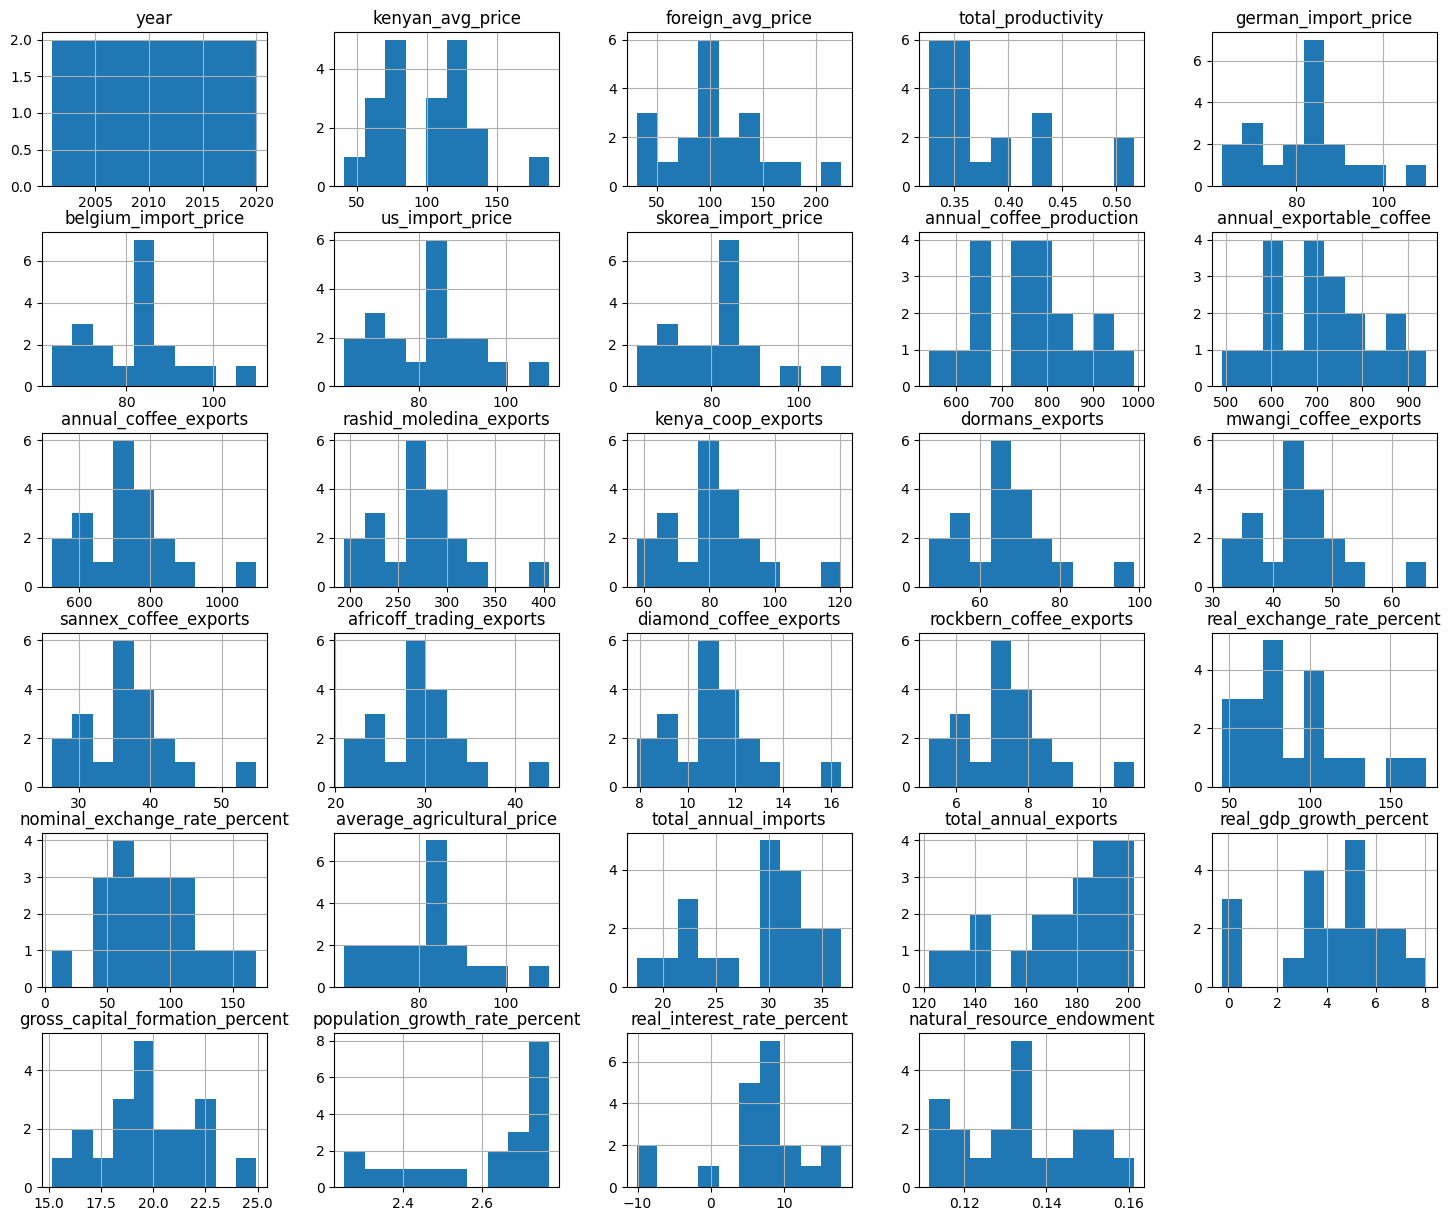

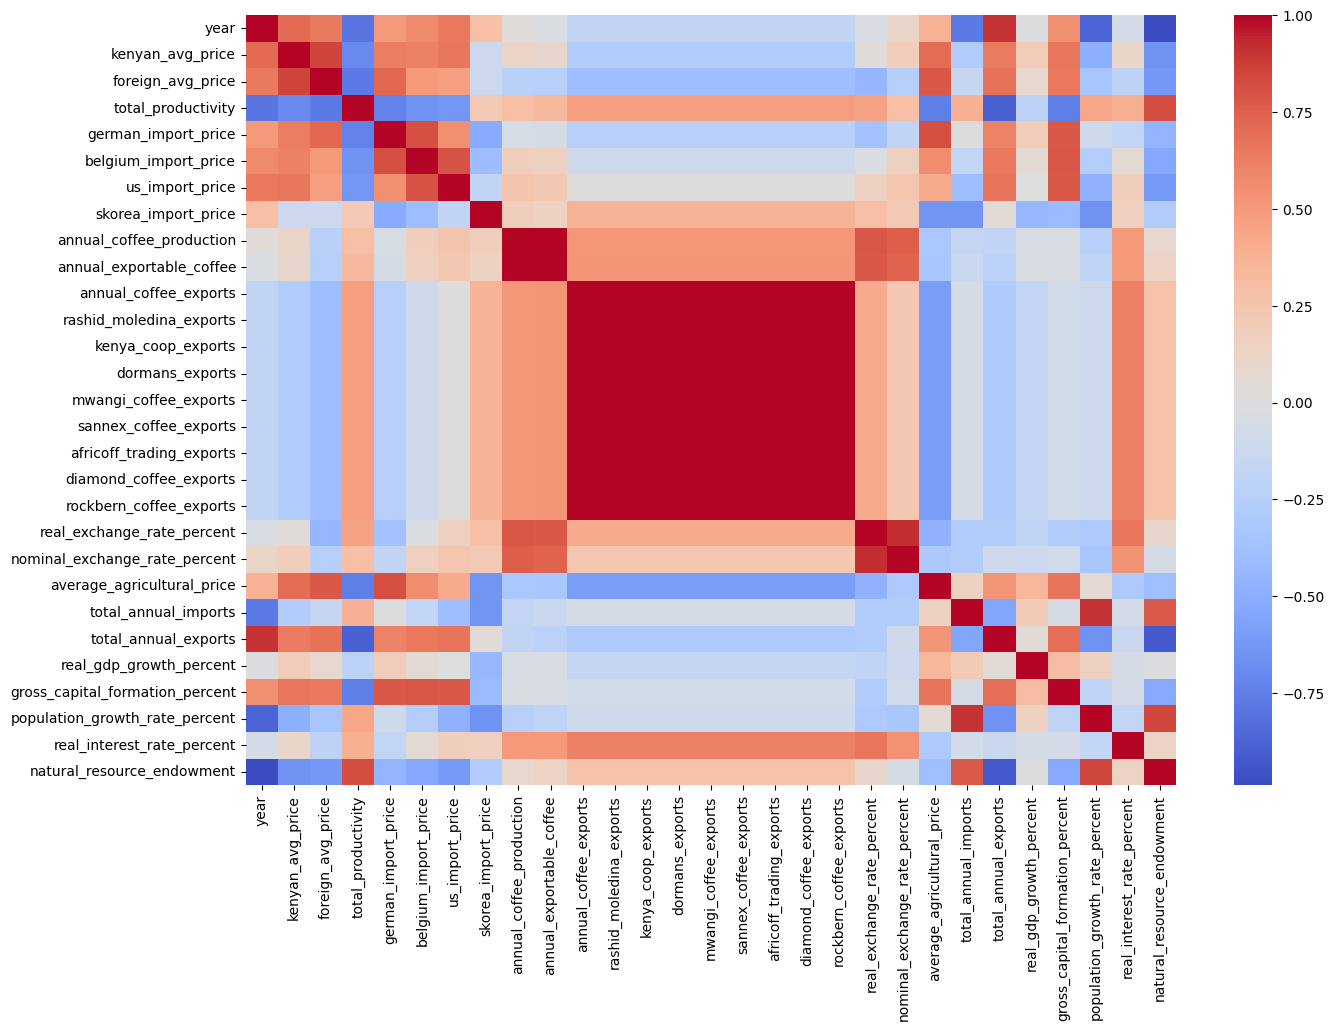

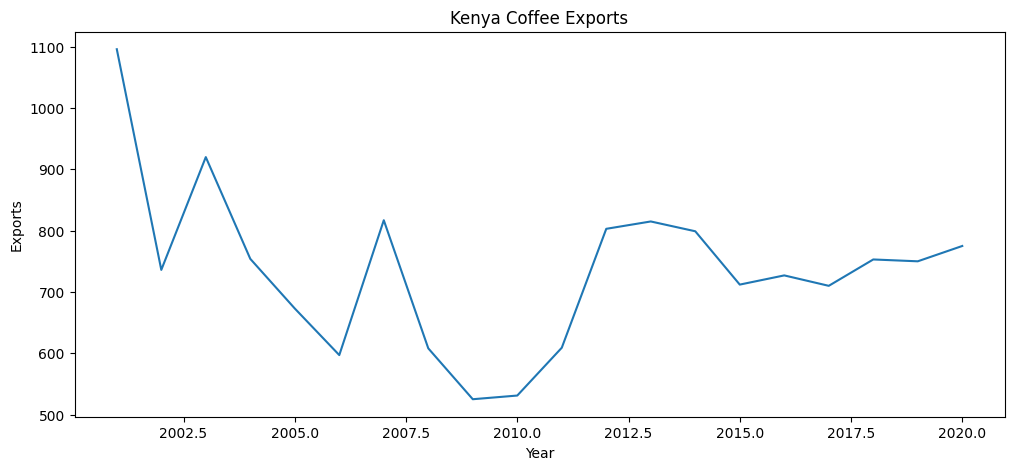

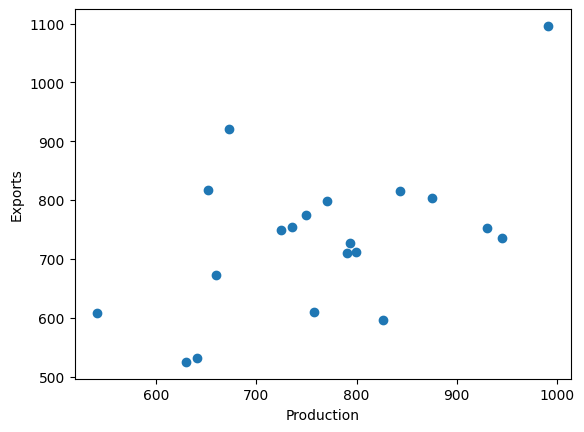

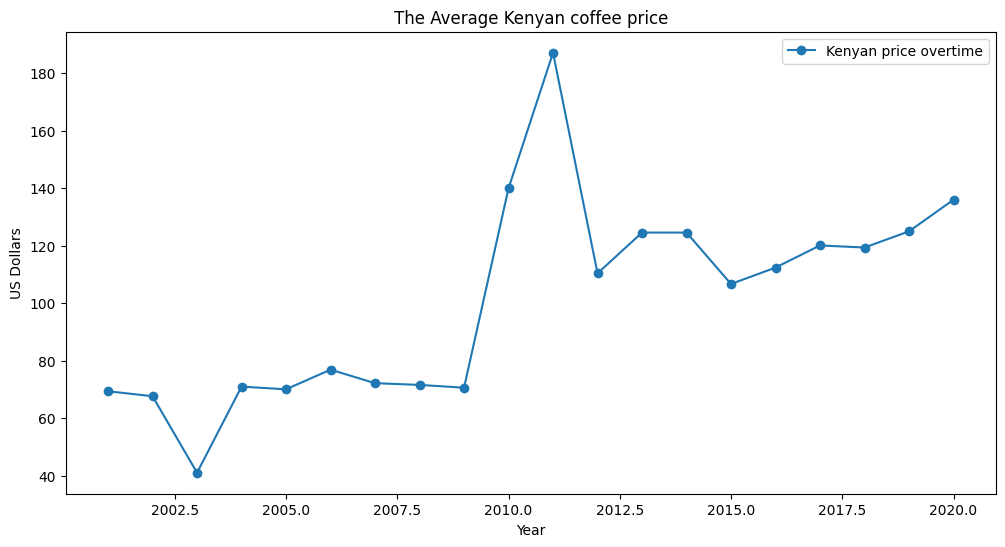

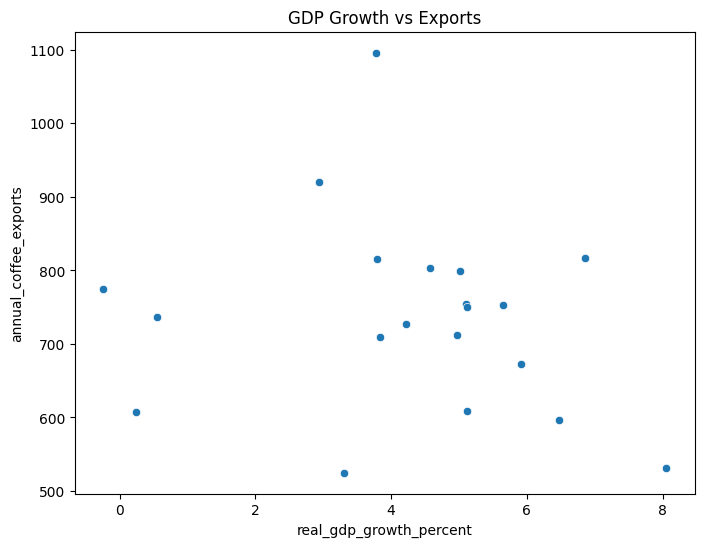

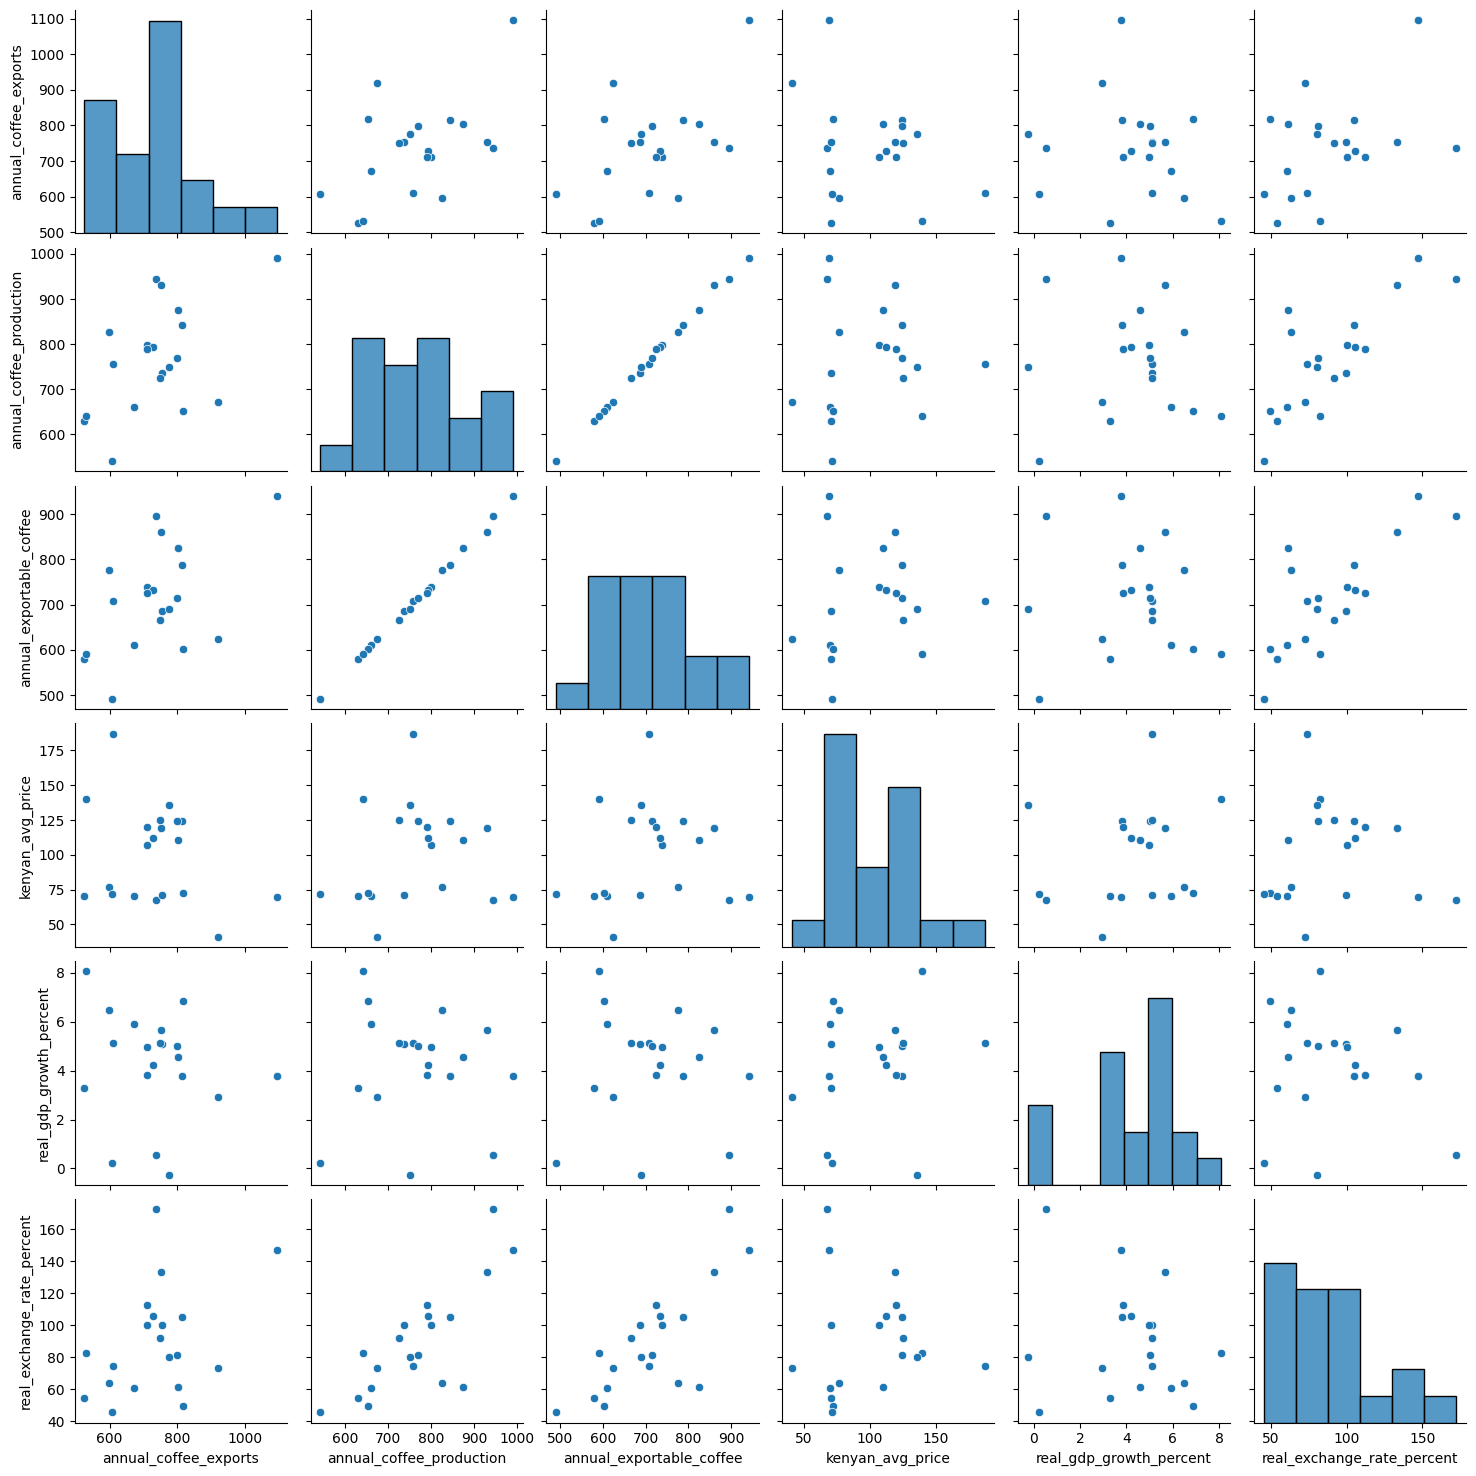

In [11]:
#EXPLORATORY DATA ANALYSIS



#have a diagram to  better understand the data
histogram = df.hist(figsize=(18,15))
print(histogram)

#correlation of the various data
correlation = df.corr(numeric_only=True)
correlation

#seaborn to create a heatmap of the data
plt.figure(figsize=(15,10))

sns.heatmap(correlation, cmap="coolwarm", annot=False )
plt.show()

#the amount of coffee exports over time = How much have we exported over time
plt.figure(figsize=(12,5))

plt.plot(df["year"],
         df["annual_coffee_exports"])

plt.xlabel("Year")
plt.ylabel("Exports")
plt.title("Kenya Coffee Exports")

plt.show()

#comparison between exports and imports = Which one has a more bigger market, import or export
plt.scatter(df["annual_coffee_production"],
            df["annual_coffee_exports"])

plt.xlabel("Production")
plt.ylabel("Exports")

plt.show()


#The coffee price over time = How has the price of coffee gone over the years
plt.figure(figsize=(12,6))
plt.plot(df["year"], df["kenyan_avg_price"], marker="o", label="Kenyan price overtime")

plt.title("The Average Kenyan coffee price")
plt.xlabel("Year")
plt.ylabel("US Dollars")
plt.legend()
plt.show()

#GDP in comparison with exports = This is for answering the question (does an increase in export have a significance in gdp growth)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="real_gdp_growth_percent",
    y="annual_coffee_exports",
    data=df
)

plt.title("GDP Growth vs Exports")

plt.show()


#pair plot = hii ni ya to better understand and visualize the paired distributions
pairs = df[
    [
        "annual_coffee_exports",
        "annual_coffee_production",
        "annual_exportable_coffee",
        "kenyan_avg_price",
        "real_gdp_growth_percent",
        "real_exchange_rate_percent"
    ]
]

sns.pairplot(pairs)

plt.show()


In [12]:
# checking for null values in the columns
print(df.isnull().sum())

# drop all unecessary columns that are not needed for the analysis
# df = df.drop(columns=[
#     "germany_import_coffee_price_usd", "belgium_import_coffee_price_usd", "united_states_import_coffee_price_usd",
#     "south_korea_import_coffee_price_usd", "rashid_moledina_exports", "kenya_cooperative_coffee_exporters_exports",
#     "dormans_exports", "mwangi_coffee_exporters_exports", "sannex_coffee_exports",
#     "africoff_trading_exports", "diamond_coffee_company_exports", "rockbern_coffee_group_exports","nominal_exchange_rate_percent","annual_exportable_coffee"
# ])

print(df.columns)
print(df.shape)
#  the 8 individual columns were dropped as they are not real independent data every single 
# one of them has a fixed propotion of the tottal exports and applied indetically across all the years. 
# The columns were dropped to avoid multicollinearity in the model and to avoid overfitting the model.

year                               0
kenyan_avg_price                   0
foreign_avg_price                  0
total_productivity                 0
german_import_price                0
belgium_import_price               0
us_import_price                    0
skorea_import_price                0
annual_coffee_production           0
annual_exportable_coffee           0
annual_coffee_exports              0
rashid_moledina_exports            0
kenya_coop_exports                 0
dormans_exports                    0
mwangi_coffee_exports              0
sannex_coffee_exports              0
africoff_trading_exports           0
diamond_coffee_exports             0
rockbern_coffee_exports            0
real_exchange_rate_percent         0
nominal_exchange_rate_percent      0
average_agricultural_price         0
total_annual_imports               0
total_annual_exports               0
real_gdp_growth_percent            0
gross_capital_formation_percent    0
population_growth_rate_percent     0
r

## observation on data cleaning
Observations made on Feature Engineering
step 1 : price gap in USD how competitely priced is kenya coffee vs the international market.

Positive gap → foreign buyers pay more elsewhere → Kenya is cheaper → demand advantage Negative gap → Kenya prices its coffee above foreign market → possible demand loss in 9 of 20 years kenyay's coffe was priced above the international market price. In 11 of the 20 years kenya's coffee was priced below the international market price. The average price gap is -0.13 USD which means that on average kenya's coffee is priced below the international market price by 0.13 USD. meaning kenya coffee commanded a quality premium as the gap turnd positive from 2005 onwards. reflecting the rise in commodity price ad growing coffee demand in the international market.

step 2: the volume interactions

Approximates total coffee revenue earned by Kenyan exporters Directly tied to what drives total export value. The 2010–2011 commodity supercycle is clearly visible — the global coffee price spike drove revenue from 37K to 114K in just 2 years, then crashed back. This interaction feature captures that joint price×quantity effect that neither variable captures alone. It is one of the most economically meaningful features in the entire engineered set.

step 3: what shares of Kenyan coffee got exported

this flags anamolous years where kenya exported more coffee than it produced, which is not possible.

step 4: growth of Kenyan coffee export over time

growth of the exports for 20 years starting from 1 for the first year in the dataset
trend_index is useful: When detrending your data first when you want to explicitly model "how much does each additional year of sector development add to exports"

step 5: year on year growth of coffee exports

how fast is kenya's coffee exports growing year on year, this is a measure of the growth of kenya's coffee exports over time. the weak correlations with the target (all under ±0.14) suggest that the rate of price change matters less than the level for predicting total exports. Lasso will likely zero these out — but including them lets the model confirm this empirically rather than us assuming it.

step 6: last year export value and price

lag 1 total exports is the stronest predictor of total exports, and lag 1 kenya price is the second strongest predictor of total exports. it captures exports momentum years that follow with strong momentum tend to to be strong themselves

step 7: production gap

2003 had the worst stockpile drawdown 0f -247 kenya exported 247 more bags than it produced drawing heavily on reserves likely because global prices rose that year making it profitable to export more than was produced. helps the model to distinguish between years hen exports are high because of strong reflecting geniuneproduction vs stockpile liquidation.

step 8: trade openness

used for statistical control of the overall size of the economy, which can affect exports through many channels. CANNOT BE USED AS A PREDICTOR OF EXPORTS, AS IT IS A FUNCTION OF EXPORTS.

step 9: credit condition:

high credit conditions (low interest rates) make it cheaper to borrow money to finance exports, which can increase exports. real interest rates are negatively correlated with exports, as expected. The correlation is weak, but it is still useful to include in the model as a control variable. negating the rate we get a credit condition index that is higher better for exports maing the model coefficient positive and economcally interpretable.

## FEATURE ENGINEERING
New columns that will fit the model properly before modelling


In [ ]:


# step 1 : price gap in USD how competitely priced is kenya coffee vs the international market.

df['price_gap_usd'] = (
    df['kenyan_avg_price'] - df['kenyan_avg_price']
).round(3)



#STEP 2: THE VOLUME INTERACTIONS
df['price_volume_interaction'] = (df['kenyan_avg_price'] * df['annual_coffee_exports']).round(3)


# STEP 3: EXPORT INTENSITY WHAT SHARE OF KENYA'S COFFEE PRODUCTION GETS EXPORTED
#values > 1 export more than produced, values < 1 export less than produced, values = 1 export exactly what is produced
df['export_intensity'] = (df['annual_coffee_exports'] / df['annual_coffee_production']).round(3)

# this flags anamolous years where kenya exported more coffee than it produced, which is not possible.

#STEP 4: TREND INDEX THE GROWTH OF KENYA'S COFFEE EXPORTS OVER TIME
df['trend_index'] = df['year'] - df['year'].min() + 1 

# STEP 5: year on year growth of coffee exports
# how fast is kenya's coffee exports growing year on year, this is a measure of the growth of kenya's coffee exports over time.
df['yoy_growth'] = df['kenyan_avg_price'].pct_change() * 100
df['exchange_rate_yoy_pct'] = df['real_exchange_rate_percent'].pct_change() * 100
df['foreign_price_yoy_pct'] = df['kenyan_avg_price'].pct_change() * 100

# the weak correlations with the target (all under ±0.14) suggest that the rate of price change matters less than the level for predicting total exports. 
# Lasso will likely zero these out — but including them lets the model confirm this empirically rather than us assuming it.


# STEP 6: LAST YEARS EXPORT VALUE AND PRICE
df['lag1_total_exports'] = df['total_annual_exports'].shift(1)
df['lag1_kenya_price'] = df['kenyan_avg_price'].shift(1)



# STEP 7: PRODUCTION GAP 
df['production_gap'] = (df['annual_coffee_production'] - df['annual_coffee_exports']).round(3)


# STEP 8: TRADE OPENNESS
df['trade_openness'] = df['total_annual_imports'] + df['total_annual_exports']


# STEP 9: CREDIT CONDITION
df['credit_condition'] = df['real_interest_rate_percent']

print(df.head(10))
df = df.dropna().reset_index(drop=True)
print(df.head(10))
print(df.shape)



   year  kenyan_avg_price  foreign_avg_price  total_productivity  \
0  2001         69.400000              37.05            0.516281   
1  2002         67.670000              30.91            0.503528   
2  2003         41.070000              42.82            0.436189   
3  2004         71.010000              56.33            0.425102   
4  2005         70.079945              87.09            0.439443   
5  2006         76.904891              87.02            0.384618   
6  2007         72.209092              98.30            0.391849   
7  2008         71.608141             109.26            0.376927   
8  2009         70.624260             100.80            0.354472   
9  2010        139.971150             134.00            0.343766   

   german_import_price  belgium_import_price  us_import_price  \
0            71.146945             76.566834        77.745437   
1            62.881144             71.146945        76.566834   
2            66.923841             62.881144        71.1

##  DATA MODELLING
since the dataset is a small datset this reinforces the use of LOOCV rather than train/split  it uses all the 19 rows for both training and validation.
nd use the regularised regression lasso

We shall be using the following in data models to serve the following purposes:
1. Linear regression: This will be used in creating the baseline
2. LASSO: This regression will be useful since it will help in reducing overfitting and performs feature selection
3. Random Forest: This is tol help in building a non linear model

In [14]:
#1. features that we shall use in the data modelling
X = df.drop("annual_coffee_exports", axis=1)

y = df["annual_coffee_exports"]

#2. scaling the features, we shall use standardscaler from scikit-learning
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#implementing the LOOCV
nyefnyef = LeaveOneOut()

In [15]:
#1ST MODEL = Linear Regression = Hii ni ya kujenga baseline

#1. training the model
linear = LinearRegression()
linear.fit(X_scaled, y)

#2. prediction
linear_predictions = cross_val_predict(
    linear,
    X_scaled,
    y,
    cv=nyefnyef
)



In [16]:
#2nd model = Lasso Regression

alphas = np.logspace(-4,2,100)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=nyefnyef,
    random_state=42
)

lasso_cv.fit(X_scaled,y)

print(lasso_cv.alpha_)

#prediction
lasso_predictions = cross_val_predict(
    Lasso(alpha=lasso_cv.alpha_),
    X_scaled,
    y,
    cv=nyefnyef
)

0.026560877829466867


In [17]:
#3rd model = Random Forest

#The hyper parameter grid = this is fot setting the parameters and the values we shall be using on them
parameters = {

    "n_estimators":[50,100,200],

    "max_depth":[2,3,5,None],

    "min_samples_split":[2,4],

    "min_samples_leaf":[1,2]
}


#grid search = This is the creation of 
rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(

    rf,

    parameters,

    cv=nyefnyef,

    scoring="neg_mean_squared_error"

)

grid.fit(X,y)

#best model
best_rf = grid.best_estimator_

print(best_rf)

#preidction
rf_predictions = cross_val_predict(
    best_rf,
    X,
    y,
    cv=nyefnyef
)

RandomForestRegressor(max_depth=5, random_state=42)


The linear regression answer is:  (2.1084289178187716, 9.213112170365752, np.float64(3.0353108852909534), 0.9990973253879999)
The lasso results are:  (0.03780795990190343, 0.0024452513104627933, np.float64(0.04944948240844178), 0.9999997604212087)
The random forest results are:  (27.855105263157924, 1703.2389140672526, np.float64(41.27031516801456), 0.8331214797487773)


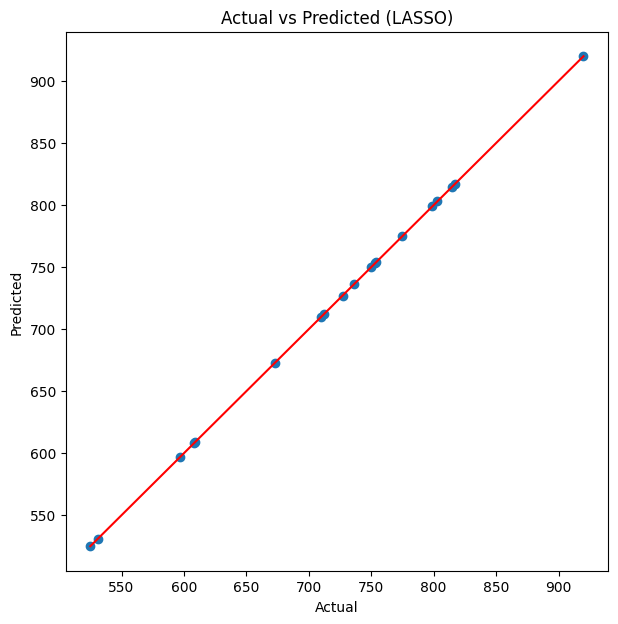

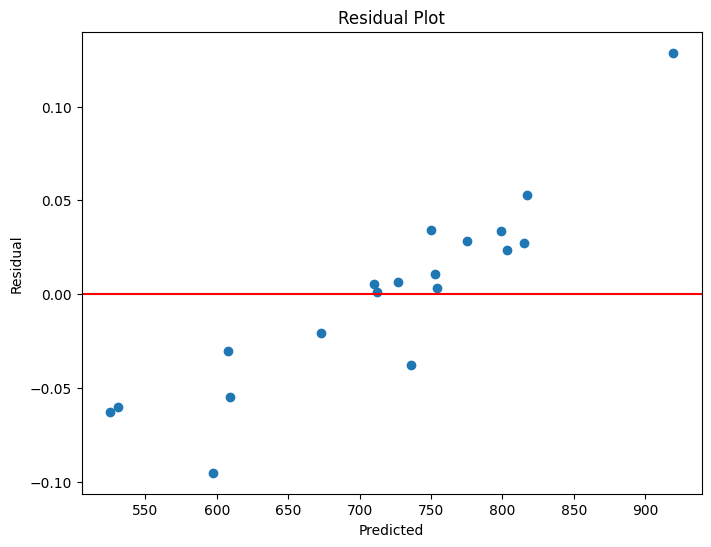

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,2.108429,9.213112,3.035311,0.999097
1,LASSO Regression,0.037808,0.002445,0.049449,1.000000
2,Random Forest,27.855105,1703.238914,41.270315,0.833121


In [18]:
#MODEL EVULATION

def model_evaluation(actual,predicted):
     mae = mean_absolute_error(actual,predicted)


     mse = mean_squared_error(actual,predicted)

     rmse = np.sqrt(mse)

     r2 = r2_score(actual,predicted)

     return mae,mse,rmse,r2

#evaluations of every model

#1. linear regression
linear_regression = model_evaluation(y,linear_predictions)
print("The linear regression answer is: ", linear_regression)

#2. lasso regression results
lasso_results = model_evaluation(y,lasso_predictions)
print("The lasso results are: ", lasso_results)

#3. Random forest results
rf_results = model_evaluation(y,rf_predictions)
print("The random forest results are: ", rf_results)




#comparison table for the data
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "LASSO Regression",

        "Random Forest"

    ],

    "MAE":[

        linear_regression[0],

        lasso_results[0],

        rf_results[0]

    ],

    "MSE":[

        linear_regression[1],

        lasso_results[1],

        rf_results[1]

    ],

    "RMSE":[

        linear_regression[2],

        lasso_results[2],

        rf_results[2]

    ],

    "R²":[

        linear_regression[3],

        lasso_results[3],

        rf_results[3]

    ]

})



# lasso visualization
plt.figure(figsize=(7,7))

plt.scatter(y,lasso_predictions)

plt.plot(

    [y.min(),y.max()],

    [y.min(),y.max()],

    color="red"

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted (LASSO)")

plt.show()



#a plot for the residual figures
residuals = y-lasso_predictions

plt.figure(figsize=(8,6))

plt.scatter(lasso_predictions,residuals)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()



results

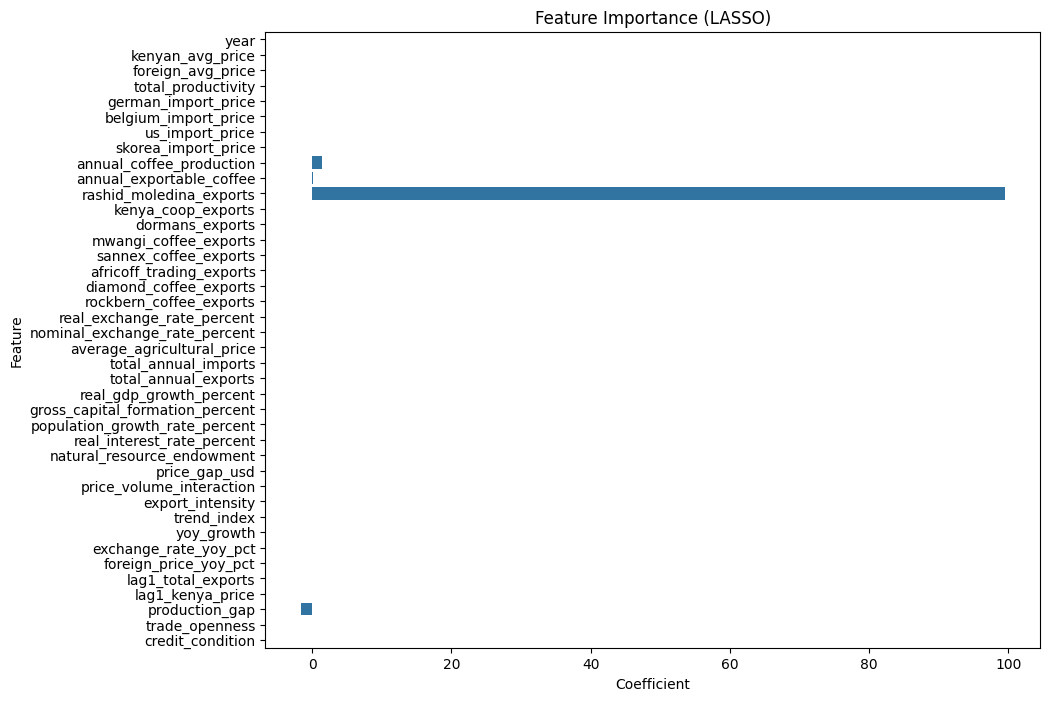

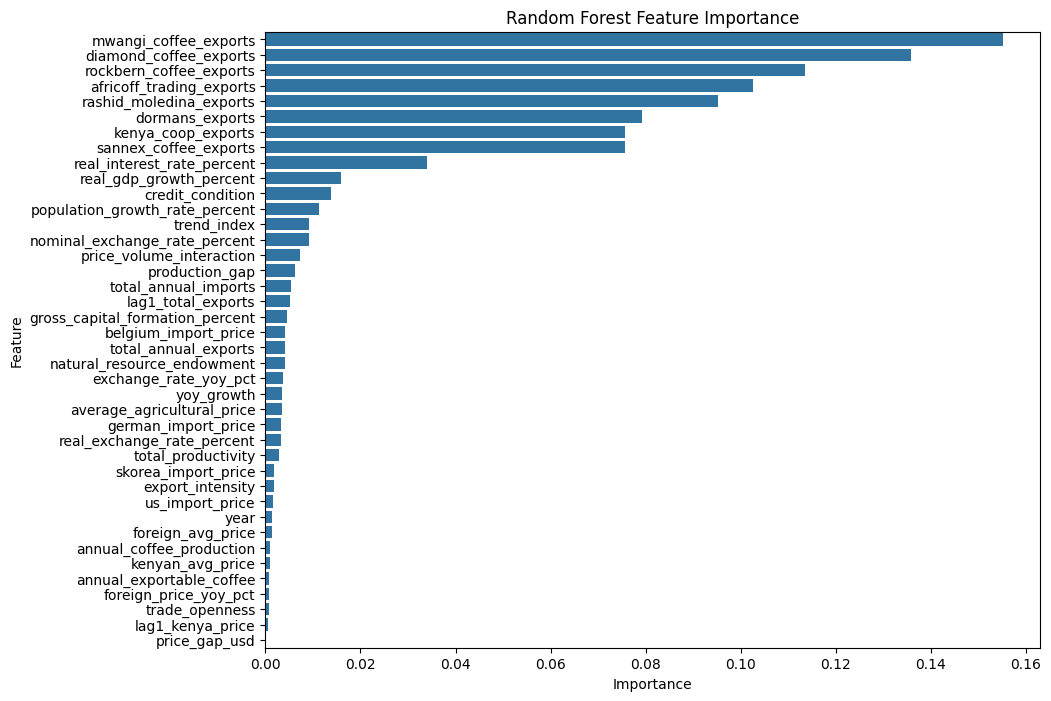

In [19]:
#RESULTS INTEPRETATION (10 Marks)

#feature importance of LASSO
lasso = Lasso(alpha=lasso_cv.alpha_)

lasso.fit(X_scaled,y)

#A well detailed data frame where we can better state it
lasso_importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":lasso.coef_

})

importance = lasso_importance.sort_values(

    by="Coefficient",

    key=abs,

    ascending=False

)

lasso_importance

#plotting of the data
plt.figure(figsize=(10,8))

sns.barplot(

    data=lasso_importance,

    x="Coefficient",

    y="Feature"

)

plt.title("Feature Importance (LASSO)")

plt.show()





#random forest 
best_rf.fit(X,y)

rf_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

rf_importance = rf_importance.sort_values(

    by="Importance",

    ascending=False

)

rf_importance



#plotting of random forest
plt.figure(figsize=(10,8))

sns.barplot(

    data=rf_importance,

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

In [22]:
#saving the models
joblib.dump(best_rf,"model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']